In [7]:
!pip install easyocr opencv-python pandas numpy


In [2]:
INPUT_FOLDER = "/content/drive/MyDrive/capstone/dataset/Dataset ocr 1.multiclass/train"
OUTPUT_FILE = "/content/dataset_transaksi.csv"

In [3]:
import os

print("Isi folder:")
print(os.listdir(INPUT_FOLDER))

Isi folder:
['X51005745296_jpg.rf.KExg1FigHMl3NZIdWbUX.jpg', 'X51005705729_jpg.rf.fhm2sLZbsyv9rUJyQk8D.jpg', 'X51005705760_jpg.rf.QUYAPPhuQXx1UWGocZ6B.jpg', 'X51005433553_jpg.rf.ao9RpNXvFXOIsSzjb8OF.jpg', 'X51005442394_jpg.rf.T2BET4vkNlxA3csDXfyF.jpg', 'X51005705727_jpg.rf.f0IY7a03lUNmjqREiQ1y.jpg', 'X51005442386_jpg.rf.OmYlUswcVe71XlZ7kqSj.jpg', 'X51005746207_jpg.rf.W5LjaLb4hnCtgK9v9H4L.jpg', 'X51005711452_jpg.rf.e1JCZKtRksc3Ag1Y0Juh.jpg', 'X51005442334_jpg.rf.SQpyGP0bqK4QmLP0GlOl.jpg', 'X51005444046_jpg.rf.W2jRlWVAG2ijnb3LqPme.jpg', 'X51005757201_jpg.rf.9XDneur9adbbkIDYvH9H.jpg', 'X51005711441_jpg.rf.gNYJLxioJE1qngQtVkLZ.jpg', 'X51005447851_jpg.rf.2ECLMEIvjaEua0JrkUsQ.jpg', 'X51005442366_jpg.rf.qLFjlUsLBhz3PfTDmKw6.jpg', 'X51005361900_jpg.rf.BixpxUJvg3Ngp8QHt3Op.jpg', 'X51005441401_jpg.rf.WKSlBOcp7EllIkyspHhg.jpg', 'X51005677337_jpg.rf.mk9aZE3tESrGbCG5Ncbu.jpg', 'X51005444044_jpg.rf.6nYYxKpd0f9AZYuPsFRQ.jpg', 'X51005677334_jpg.rf.0AVi82Z2wELNpaMaJoxZ.jpg', 'X51005361907_jpg.rf.LCA3hm

In [4]:
import easyocr
import os
import re
import pandas as pd
import cv2

# init OCR
reader = easyocr.Reader(['en'], gpu=False)

data = []

# =========================
# HELPER
# =========================

def normalize_text(text):
    text = text.replace("RM", "")
    text = text.replace(",", "")
    return text.strip()

def extract_date(text):
    patterns = [r"\d{2}/\d{2}/\d{4}", r"\d{2}-\d{2}-\d{4}"]
    for p in patterns:
        match = re.search(p, text)
        if match:
            return match.group(0)
    return None

def extract_total(text):
    match = re.search(r"Total.*?(\d+\.\d{2})", text, re.IGNORECASE)
    return float(match.group(1)) if match else None

def is_item_line(line):
    return bool(re.search(r"\d+\.\d{2}", line))

def parse_item_line(line):
    numbers = re.findall(r"\d+\.\d{2}|\d+", line)

    if len(numbers) < 2:
        return None

    try:
        qty = int(numbers[-3]) if len(numbers) >= 3 else 1
        harga = float(numbers[-2])
        total = float(numbers[-1])

        name = re.split(r"\d+", line)[0].strip()

        if len(name) < 3:
            return None

        return name, qty, harga, total
    except:
        return None

# =========================
# LOOP SEMUA GAMBAR
# =========================

for file in os.listdir(INPUT_FOLDER):
    if not file.lower().endswith((".jpg", ".png", ".jpeg")):
        continue

    path = os.path.join(INPUT_FOLDER, file)
    print(f"🔍 Processing: {file}")

    # preprocessing
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # OCR
    results = reader.readtext(gray, detail=0)
    lines = [normalize_text(x) for x in results]
    full_text = "\n".join(lines)

    transaction_id = file.split(".")[0]
    tanggal = extract_date(full_text)
    total_transaksi = extract_total(full_text)

    found_item = False

    for line in lines:
        if not is_item_line(line):
            continue

        parsed = parse_item_line(line)

        if parsed:
            nama, qty, harga, total_item = parsed
            found_item = True

            data.append([
                transaction_id,
                tanggal,
                nama,
                qty,
                harga,
                total_item,
                total_transaksi
            ])

    # fallback kalau tidak ada item
    if not found_item:
        data.append([
            transaction_id,
            tanggal,
            "UNKNOWN",
            1,
            0,
            0,
            total_transaksi
        ])

# =========================
# SIMPAN CSV
# =========================

df = pd.DataFrame(data, columns=[
    "transaction_id",
    "tanggal",
    "nama_produk",
    "qty",
    "harga_satuan",
    "total_item",
    "total_transaksi"
])

# cleaning
df = df[df["harga_satuan"] > 0]
df = df[df["nama_produk"].str.len() > 3]

df.to_csv(OUTPUT_FILE, index=False)

print("\n✅ SELESAI!")
print("File:", OUTPUT_FILE)
df.head()

🔍 Processing: X51005745296_jpg.rf.KExg1FigHMl3NZIdWbUX.jpg


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


🔍 Processing: X51005705729_jpg.rf.fhm2sLZbsyv9rUJyQk8D.jpg
🔍 Processing: X51005705760_jpg.rf.QUYAPPhuQXx1UWGocZ6B.jpg
🔍 Processing: X51005433553_jpg.rf.ao9RpNXvFXOIsSzjb8OF.jpg
🔍 Processing: X51005442394_jpg.rf.T2BET4vkNlxA3csDXfyF.jpg
🔍 Processing: X51005705727_jpg.rf.f0IY7a03lUNmjqREiQ1y.jpg
🔍 Processing: X51005442386_jpg.rf.OmYlUswcVe71XlZ7kqSj.jpg
🔍 Processing: X51005746207_jpg.rf.W5LjaLb4hnCtgK9v9H4L.jpg
🔍 Processing: X51005711452_jpg.rf.e1JCZKtRksc3Ag1Y0Juh.jpg
🔍 Processing: X51005442334_jpg.rf.SQpyGP0bqK4QmLP0GlOl.jpg
🔍 Processing: X51005444046_jpg.rf.W2jRlWVAG2ijnb3LqPme.jpg
🔍 Processing: X51005757201_jpg.rf.9XDneur9adbbkIDYvH9H.jpg
🔍 Processing: X51005711441_jpg.rf.gNYJLxioJE1qngQtVkLZ.jpg
🔍 Processing: X51005447851_jpg.rf.2ECLMEIvjaEua0JrkUsQ.jpg
🔍 Processing: X51005442366_jpg.rf.qLFjlUsLBhz3PfTDmKw6.jpg
🔍 Processing: X51005361900_jpg.rf.BixpxUJvg3Ngp8QHt3Op.jpg
🔍 Processing: X51005441401_jpg.rf.WKSlBOcp7EllIkyspHhg.jpg
🔍 Processing: X51005677337_jpg.rf.mk9aZE3tESrGbCG5Ncbu.j

,transaction_id,tanggal,nama_produk,qty,harga_satuan,total_item,total_transaksi
1,X51005705729_jpg,13/10/2017,Timne:,1,11.37,0.00,NaN
5,X51005705727_jpg,28/12/2017,Time:,1,10.50,0.00,NaN
6,X51005442386_jpg,None,GST @,8,6.00,50.49,58.7
11,X51005757201_jpg,28/02/2018,DISC,1,10.00,8.01,NaN
12,X51005757201_jpg,28/02/2018,OISC',1,10.00,2.25,NaN


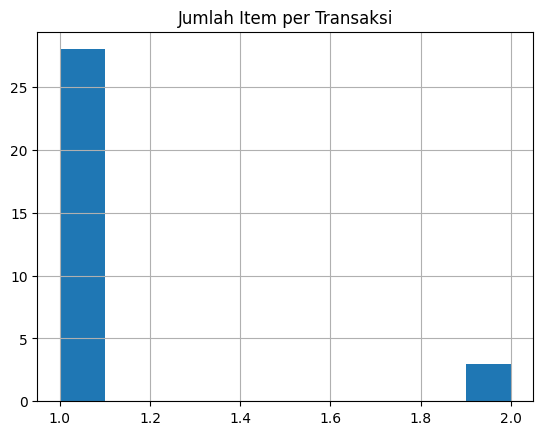

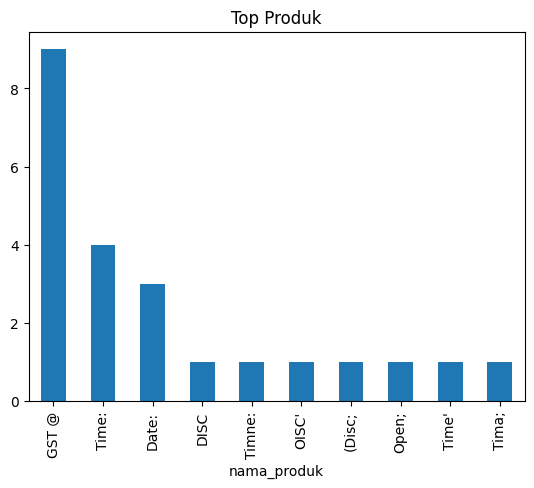

In [5]:
import matplotlib.pyplot as plt

# jumlah item per transaksi
df.groupby("transaction_id")["nama_produk"].count().hist()
plt.title("Jumlah Item per Transaksi")
plt.show()

# top produk
df["nama_produk"].value_counts().head(10).plot(kind="bar")
plt.title("Top Produk")
plt.show()

In [6]:
from google.colab import files
files.download('/content/dataset_transaksi.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>